# Modeling Human Activity States Using Hidden Markov Models

**Background and motivation**

Wearable and mobile sensors continuously produce accelerometer and gyroscope
signals, but the underlying activity generating those signals — standing,
walking, jumping, or remaining still — is not directly observed; it must be
inferred. This project treats activity recognition as a Hidden Markov Model
(HMM) problem: the true activity is a hidden state sequence, and the sensor
readings (summarized into engineered features per time window) are noisy
observations generated by that hidden state. Reliable activity recognition
from phone sensors underlies applications such as fall detection, fitness
tracking, and context-aware mobile interfaces, making this a practically
motivated instance of sequential state inference.

**Note on data provenance:** Due to time constraints, the raw sensor
recordings used in this project were provided by a colleague (with
permission) rather than personally collected. All data loading, sampling-rate
harmonization, feature engineering, HMM implementation, training, and
evaluation in this notebook are original work.


## 1. Data Collection and Preprocessing

### 1.1 Loading and sampling-rate harmonization

The dataset consists of 54 short recordings (5-12s each) across four
activities -- **standing, walking, jumping, still** -- captured with a phone
motion-logging app at either **50Hz or 100Hz**. Because the two rates cannot
be modeled together directly (a 100Hz window contains twice as many samples
per second as a 50Hz window of the same duration), all recordings are
harmonized to a single common rate of **50Hz**.

We chose to **downsample the 100Hz files to 50Hz** rather than upsample the
50Hz files to 100Hz. Downsampling (via `scipy.signal.decimate`, which applies
an anti-aliasing low-pass filter before subsampling) only removes information
that is already redundant at the target rate. Upsampling, in contrast, would
require interpolating values that were never actually measured, fabricating
data points that don't correspond to real sensor readings. Since 100 is an
exact integer multiple of 50, decimation by a factor of 2 is exact and
clean.


In [1]:
!pip install hmmlearn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import glob, os
from scipy.signal import decimate
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random


TARGET_FS = 50
ACTIVITIES = ['standing', 'walking', 'jumping', 'still']

random.seed(42)
np.random.seed(42)


In [3]:
RAW_DIR = "data/raw"

In [4]:
FIGURES_DIR = "plots"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [5]:
def load_and_harmonize(raw_dir=RAW_DIR, target_fs=TARGET_FS):
    files = sorted(glob.glob(os.path.join(raw_dir, "*.csv")))
    sessions = {}
    signal_cols = ['acc_x','acc_y','acc_z','gyr_x','gyr_y','gyr_z','grav_x','grav_y','grav_z']

    for f in files:
        df = pd.read_csv(f)
        fname = os.path.basename(f).replace(".csv", "")
        fs = int(df['fs_hz'].iloc[0])
        activity = df['activity'].iloc[0]

        if fs == target_fs:
            df_out = df[signal_cols].copy()
        elif fs > target_fs and fs % target_fs == 0:
            factor = fs // target_fs
            decimated = {col: decimate(df[col].values, factor, zero_phase=True) for col in signal_cols}
            df_out = pd.DataFrame(decimated)
        else:
            raise ValueError(f"Unexpected fs={fs} in {fname}, cannot cleanly decimate to {target_fs}")

        df_out['activity'] = activity
        df_out['fs_hz'] = target_fs
        df_out['session_id'] = fname
        sessions[fname] = df_out
    return sessions

sessions = load_and_harmonize()
print(f"Loaded and harmonized {len(sessions)} recording sessions")
acts = Counter(df['activity'].iloc[0] for df in sessions.values())
print("Sessions per activity:", dict(acts))

total_seconds = defaultdict(float)
for df in sessions.values():
    total_seconds[df['activity'].iloc[0]] += len(df) / TARGET_FS
print("\nTotal recorded seconds per activity (after harmonization):")
for act, secs in total_seconds.items():
    print(f"  {act}: {secs:.1f}s")


Loaded and harmonized 54 recording sessions
Sessions per activity: {'jumping': 13, 'standing': 13, 'still': 13, 'walking': 15}

Total recorded seconds per activity (after harmonization):
  jumping: 100.4s
  standing: 105.9s
  still: 113.3s
  walking: 122.5s


### 1.2 Visualizing sample recordings per activity

Before modeling, it's worth looking at what each activity actually looks
like in the raw signal. The plot below shows acceleration magnitude
(the norm of acc_x, acc_y, acc_z) over time for one representative recording
of each activity.

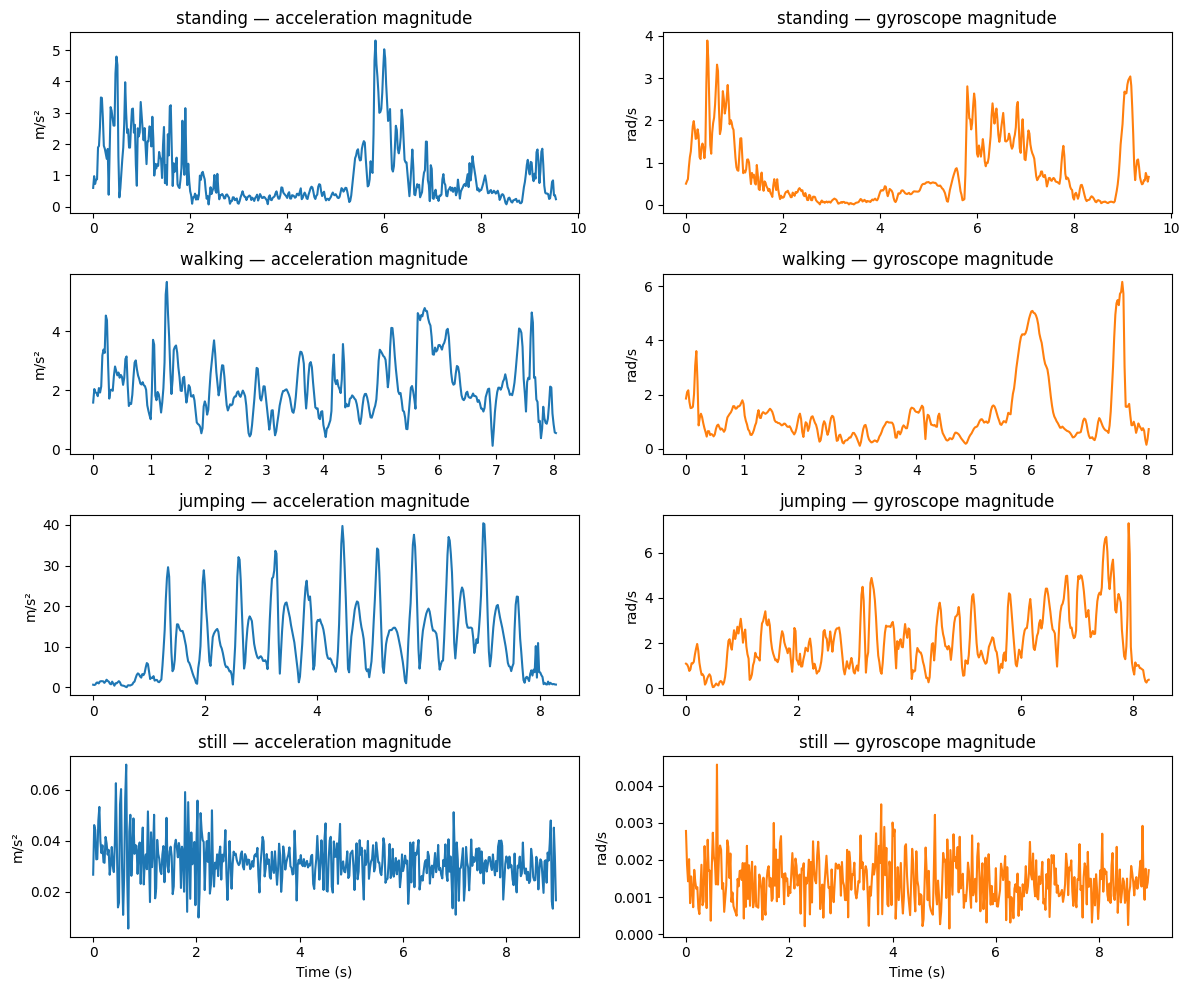

In [6]:

fig, axes = plt.subplots(len(ACTIVITIES), 2, figsize=(12, 10))

for row, act in enumerate(ACTIVITIES):
    sample = next(df for df in sessions.values() if df['activity'].iloc[0] == act)
    t = np.arange(len(sample)) / TARGET_FS

    acc_mag = np.linalg.norm(sample[['acc_x','acc_y','acc_z']].values, axis=1)
    gyr_mag = np.linalg.norm(sample[['gyr_x','gyr_y','gyr_z']].values, axis=1)

    axes[row, 0].plot(t, acc_mag, color='tab:blue')
    axes[row, 0].set_title(f"{act} — acceleration magnitude")
    axes[row, 0].set_ylabel("m/s²")

    axes[row, 1].plot(t, gyr_mag, color='tab:orange')
    axes[row, 1].set_title(f"{act} — gyroscope magnitude")
    axes[row, 1].set_ylabel("rad/s")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "raw_acc_gyro_magnitude.png"), dpi=150, bbox_inches="tight")
plt.show()

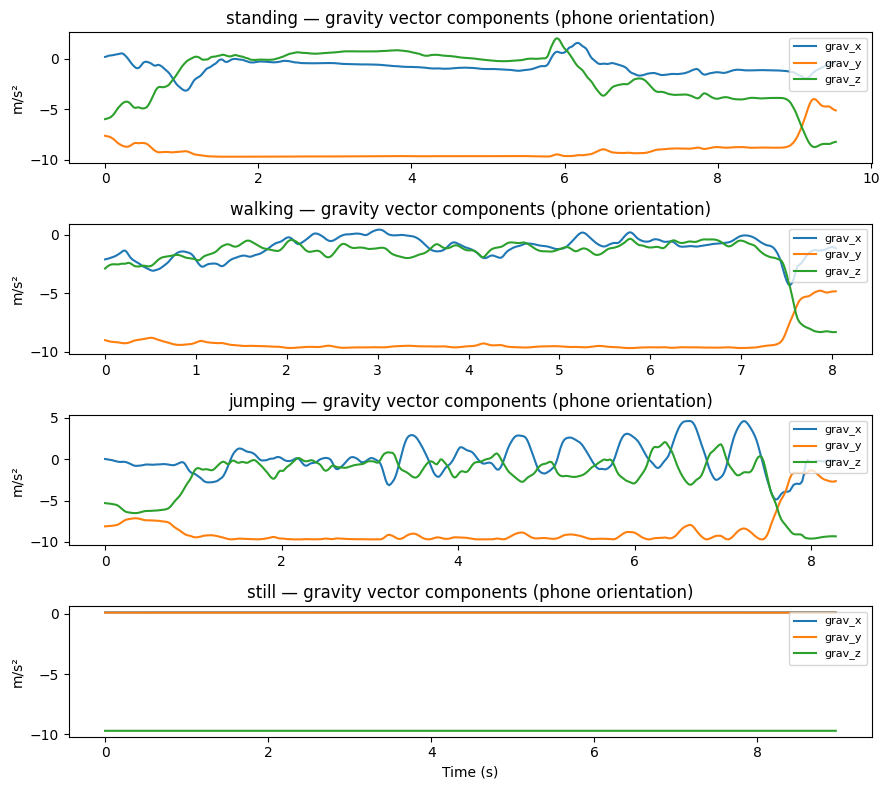

In [7]:
fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(9, 8))

for ax, act in zip(axes, ACTIVITIES):
    sample = next(df for df in sessions.values() if df['activity'].iloc[0] == act)
    t = np.arange(len(sample)) / TARGET_FS
    ax.plot(t, sample['grav_x'], label='grav_x')
    ax.plot(t, sample['grav_y'], label='grav_y')
    ax.plot(t, sample['grav_z'], label='grav_z')
    ax.set_title(f"{act} — gravity vector components (phone orientation)")
    ax.set_ylabel("m/s²")
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "gravity_orientation.png"), dpi=150, bbox_inches="tight")
plt.show()

Jumping shows large-amplitude, low-frequency spikes; walking shows a
steady rhythmic oscillation around 1-2 Hz consistent with a gait cycle;
standing and still both look nearly flat in acceleration *magnitude* alone --
these two are visually the hardest pair to tell apart from this signal alone,
which foreshadows a result we return to in the Analysis section.

### 1.3 Train / unseen-test split

Before any windowing or feature extraction, we set aside **2 complete
recording sessions per activity (8 files total)** as an unseen test set. These
files are never used for training or for feature normalization -- they
represent genuinely new data, mixing both originally-50Hz and
originally-100Hz sessions, used only once at final evaluation.

In [8]:
def split_train_test(sessions, n_test_per_activity=2, seed=42):
    rng = random.Random(seed)
    by_activity = defaultdict(list)
    for name, df in sessions.items():
        by_activity[df['activity'].iloc[0]].append(name)

    test_names = set()
    for act, names in by_activity.items():
        chosen = rng.sample(sorted(names), n_test_per_activity)
        test_names.update(chosen)

    train_sessions = {k: v for k, v in sessions.items() if k not in test_names}
    test_sessions = {k: v for k, v in sessions.items() if k in test_names}
    return train_sessions, test_sessions

train_sessions, test_sessions = split_train_test(sessions)
print(f"Training sessions: {len(train_sessions)}")
print(f"Held-out (unseen) test sessions: {len(test_sessions)}")
print("\nHeld-out test files:")
for name, df in sorted(test_sessions.items()):
    print(" ", name, "-", df['activity'].iloc[0])


Training sessions: 46
Held-out (unseen) test sessions: 8

Held-out test files:
  jumping_100hz_02 - jumping
  jumping_50hz_08 - jumping
  standing_100hz_01 - standing
  standing_50hz_09 - standing
  still_50hz_01 - still
  still_50hz_02 - still
  walking_100hz_03 - walking
  walking_100hz_04 - walking


## 2. Windowing

Raw sensor samples are too fine-grained to serve directly as HMM
observations -- a single 50Hz sample carries almost no information about
which activity is occurring. Instead, we segment each recording into
**windows** and compute summary features per window; each window becomes one
observation in the HMM's observation sequence.

**Window size: 2.0 seconds (100 samples at 50Hz), with 50% overlap (1.0s
stride).** This choice mirrors standard practice in human activity
recognition literature (e.g., the widely used UCI-HAR dataset uses ~2.56s
windows). Two seconds is long enough to capture at least one full gait cycle
during walking and one full jump cycle during jumping, while short enough
that each 7-12 second recording still yields multiple independent-ish
windows for training and evaluation. The 50% overlap increases the number of
usable windows without needing longer recordings.

In [9]:
WINDOW_SEC = 2.0
OVERLAP = 0.5
WINDOW_SAMPLES = int(WINDOW_SEC * TARGET_FS)            # 100
STRIDE_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))    # 50

def make_windows(df, window=WINDOW_SAMPLES, stride=STRIDE_SAMPLES):
    n = len(df)
    return [df.iloc[start:start+window] for start in range(0, n - window + 1, stride)]

# sanity check
example = next(iter(sessions.values()))
print(f"Example session length: {len(example)} samples -> {len(make_windows(example))} windows")


Example session length: 415 samples -> 7 windows


## 3. Feature Extraction

For each window we extract **21 features** spanning time-domain,
frequency-domain, and orientation information, computed from the
accelerometer, gyroscope, and gravity-vector channels.

**Time-domain features** (mean, std, RMS, min, max of acceleration and
gyroscope magnitude; Signal Magnitude Area; pairwise correlation between
acceleration axes): these capture the intensity and shape of motion
directly. Standard deviation and RMS in particular separate high-motion
activities (jumping, walking) from low-motion ones (standing, still).
Axis-correlation captures coordinated motion patterns -- e.g., walking
produces a different x/y/z coupling than jumping does.

**Frequency-domain features** (dominant frequency, spectral energy, spectral
entropy of the acceleration-magnitude FFT): periodic activities like walking
have concentrated spectral energy around a stride frequency, while
still/standing have energy concentrated near 0 Hz and jumping has energy
spread more broadly across low frequencies.

**Orientation features** (mean gravity-vector components grav_x/y/z):
motion-magnitude features alone cannot distinguish two activities that are
both "not moving much" but held at different phone orientations. Standing
(phone upright at the waist) and still (phone flat on a table) are a prime
example -- their gravity vectors point in very different directions even
though their acceleration variance is similarly low.

**Normalization:** all features are standardized to zero mean / unit
variance (Z-score) using a scaler **fit on training data only** (never on
test data, to avoid leakage). This is necessary because our features mix
very different units and scales -- acceleration (m/s^2), gyroscope (rad/s),
and spectral energy (arbitrary large units) -- and GaussianHMM's
covariance estimation assumes comparable feature scales.

In [10]:
ACC_COLS = ['acc_x', 'acc_y', 'acc_z']
GYR_COLS = ['gyr_x', 'gyr_y', 'gyr_z']
GRAV_COLS = ['grav_x', 'grav_y', 'grav_z']

def extract_features(window_df, fs=TARGET_FS):
    feats = {}
    acc = window_df[ACC_COLS].values
    gyr = window_df[GYR_COLS].values
    acc_mag = np.linalg.norm(acc, axis=1)
    gyr_mag = np.linalg.norm(gyr, axis=1)

    # --- Time-domain ---
    for name, arr in [('acc_mag', acc_mag), ('gyr_mag', gyr_mag)]:
        feats[f'{name}_mean'] = np.mean(arr)
        feats[f'{name}_std']  = np.std(arr)
        feats[f'{name}_rms']  = np.sqrt(np.mean(arr**2))
        feats[f'{name}_min']  = np.min(arr)
        feats[f'{name}_max']  = np.max(arr)

    feats['acc_sma'] = np.mean(np.sum(np.abs(acc), axis=1))
    feats['gyr_sma'] = np.mean(np.sum(np.abs(gyr), axis=1))

    for (i, j, name) in [(0,1,'acc_corr_xy'), (1,2,'acc_corr_yz'), (0,2,'acc_corr_xz')]:
        if np.std(acc[:,i]) > 1e-9 and np.std(acc[:,j]) > 1e-9:
            feats[name] = np.corrcoef(acc[:,i], acc[:,j])[0,1]
        else:
            feats[name] = 0.0

    # --- Orientation (gravity vector) ---
    grav = window_df[GRAV_COLS].values
    feats['grav_x_mean'] = np.mean(grav[:, 0])
    feats['grav_y_mean'] = np.mean(grav[:, 1])
    feats['grav_z_mean'] = np.mean(grav[:, 2])

    # --- Frequency-domain (on acceleration magnitude) ---
    n = len(acc_mag)
    windowed = acc_mag - np.mean(acc_mag)
    fft_vals = np.abs(rfft(windowed))
    freqs = rfftfreq(n, d=1.0/fs)
    if len(fft_vals) > 1:
        dom_idx = np.argmax(fft_vals[1:]) + 1
        feats['dominant_freq'] = freqs[dom_idx]
        feats['spectral_energy'] = np.sum(fft_vals**2) / n
        psd = fft_vals**2
        psd_norm = psd / (np.sum(psd) + 1e-12)
        feats['spectral_entropy'] = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
    else:
        feats['dominant_freq'] = 0.0
        feats['spectral_energy'] = 0.0
        feats['spectral_entropy'] = 0.0
    return feats

FEATURE_COLS = ['acc_mag_mean','acc_mag_std','acc_mag_rms','acc_mag_min','acc_mag_max',
                'gyr_mag_mean','gyr_mag_std','gyr_mag_rms','gyr_mag_min','gyr_mag_max',
                'acc_sma','gyr_sma','acc_corr_xy','acc_corr_yz','acc_corr_xz',
                'grav_x_mean','grav_y_mean','grav_z_mean',
                'dominant_freq','spectral_energy','spectral_entropy']

def sessions_to_feature_df(sessions):
    rows = []
    for name, df in sessions.items():
        activity = df['activity'].iloc[0]
        for w in make_windows(df):
            f = extract_features(w)
            f['activity'] = activity
            f['session_id'] = name
            rows.append(f)
    return pd.DataFrame(rows)

train_feat = sessions_to_feature_df(train_sessions)
test_feat = sessions_to_feature_df(test_sessions)

print("Train feature windows:", train_feat.shape)
print("Test feature windows:", test_feat.shape)
print("\nWindows per activity (train):")
print(train_feat['activity'].value_counts())
print("\nWindows per activity (test):")
print(test_feat['activity'].value_counts())


Train feature windows: (304, 23)
Test feature windows: (56, 23)

Windows per activity (train):
activity
walking     87
still       76
standing    71
jumping     70
Name: count, dtype: int64

Windows per activity (test):
activity
still       16
standing    14
walking     14
jumping     12
Name: count, dtype: int64


In [11]:
def build_sequences(feat_df, scaler=None, fit_scaler=False):
    session_ids = feat_df['session_id'].unique()
    X_list, lengths, labels_list = [], [], []
    for sid in session_ids:
        sub = feat_df[feat_df['session_id'] == sid]
        X_list.append(sub[FEATURE_COLS].values)
        lengths.append(len(sub))
        labels_list.append(sub['activity'].values)

    X_raw = np.vstack(X_list)
    if fit_scaler:
        scaler = StandardScaler().fit(X_raw)
    X_scaled = scaler.transform(X_raw)
    labels_flat = np.concatenate(labels_list)
    return X_scaled, lengths, labels_flat, scaler

X_train, len_train, y_train, scaler = build_sequences(train_feat, fit_scaler=True)
X_test, len_test, y_test, _ = build_sequences(test_feat, scaler=scaler, fit_scaler=False)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (304, 21) | X_test: (56, 21)


## 4. HMM Definition

| Element | Our definition |
|---|---|
| **Hidden states (Z)** | 4 states, one per activity: standing, walking, jumping, still |
| **Observations (X)** | 21-dimensional feature vector per 2-second window (time + frequency + orientation features) |
| **Transition probabilities (A)** | 4x4 matrix, learned via Baum-Welch |
| **Emission probabilities (B)** | Modeled as a multivariate Gaussian per state (GaussianHMM), since our observations are continuous feature vectors rather than discrete symbols |
| **Initial state probabilities (pi)** | Learned jointly with A and B during training |

Because we have ground-truth activity labels for training recordings, we
train the HMM **unsupervised** (states are discovered purely from the
structure of the feature sequences via Baum-Welch, without using the labels
during fitting) and afterward assign each discovered hidden state to the
activity label it aligns with most often (majority vote on training data).
This tests whether the HMM can genuinely discover activity structure from
the sensor features alone, rather than simply memorizing labels -- and lets
us use Viterbi decoding for inference exactly as intended by the model.

In [12]:
summary = train_feat.groupby('activity')[FEATURE_COLS].agg(['mean', 'std'])
pd.set_option('display.max_columns', None)
print(summary)

         acc_mag_mean           acc_mag_std           acc_mag_rms            \
                 mean       std        mean       std        mean       std   
activity                                                                      
jumping     10.081654  2.718774    6.255126  1.414674   11.893047  2.950423   
standing     0.336230  0.383767    0.224107  0.482453    0.414821  0.609189   
still        0.032123  0.005516    0.009015  0.010467    0.033850  0.010338   
walking      2.270965  2.138898    1.048759  1.432700    2.517131  2.558873   

         acc_mag_min           acc_mag_max           gyr_mag_mean            \
                mean       std        mean       std         mean       std   
activity                                                                      
jumping     1.227984  0.803340   29.174890  6.721726     1.969194  0.681294   
standing    0.052777  0.030807    1.246714  2.458937     0.168091  0.262832   
still       0.013658  0.004307    0.060930  0.04933

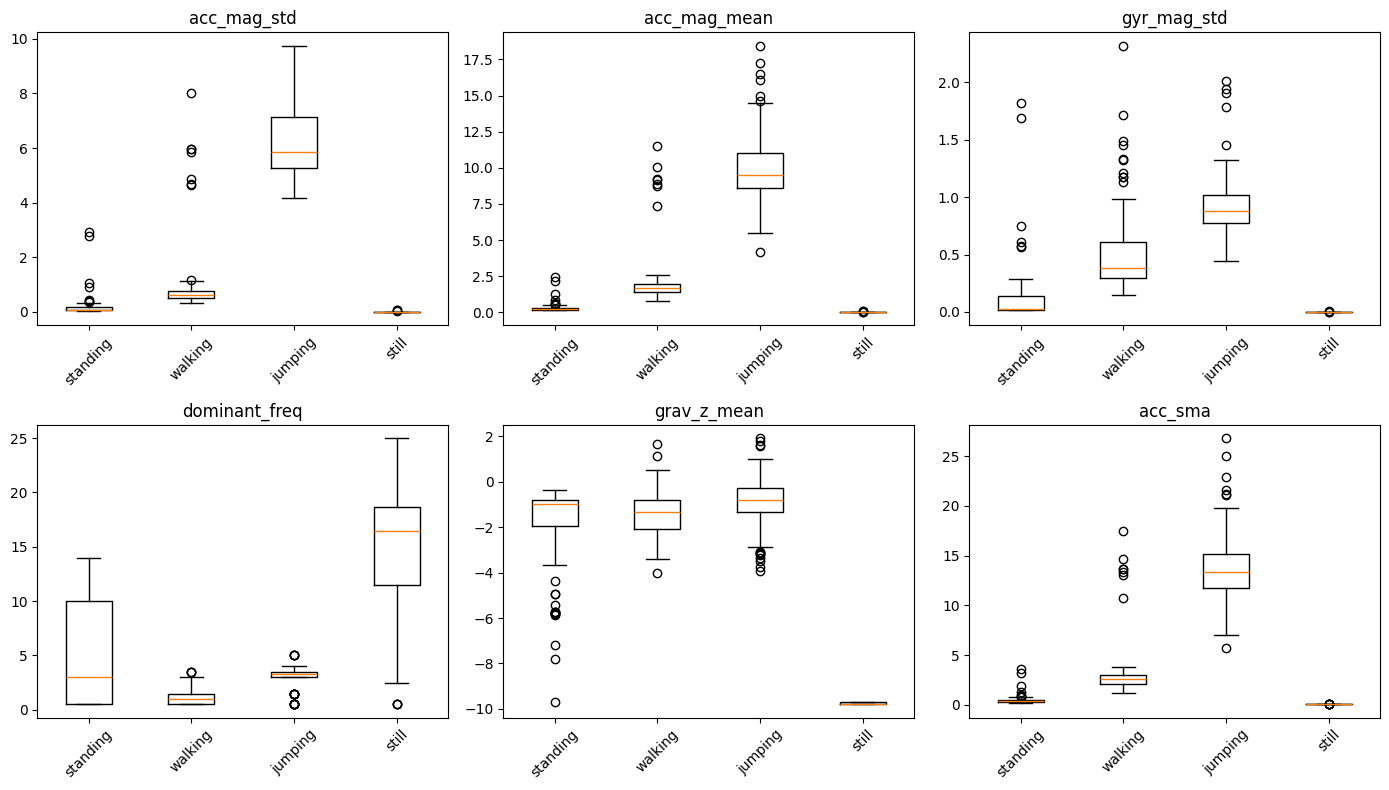

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
key_features = ['acc_mag_std', 'acc_mag_mean', 'gyr_mag_std',
                 'dominant_freq', 'grav_z_mean', 'acc_sma']

for ax, feat in zip(axes.flat, key_features):
    data = [train_feat[train_feat['activity'] == act][feat].values for act in ACTIVITIES]
    ax.boxplot(data, tick_labels=ACTIVITIES)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "feature_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

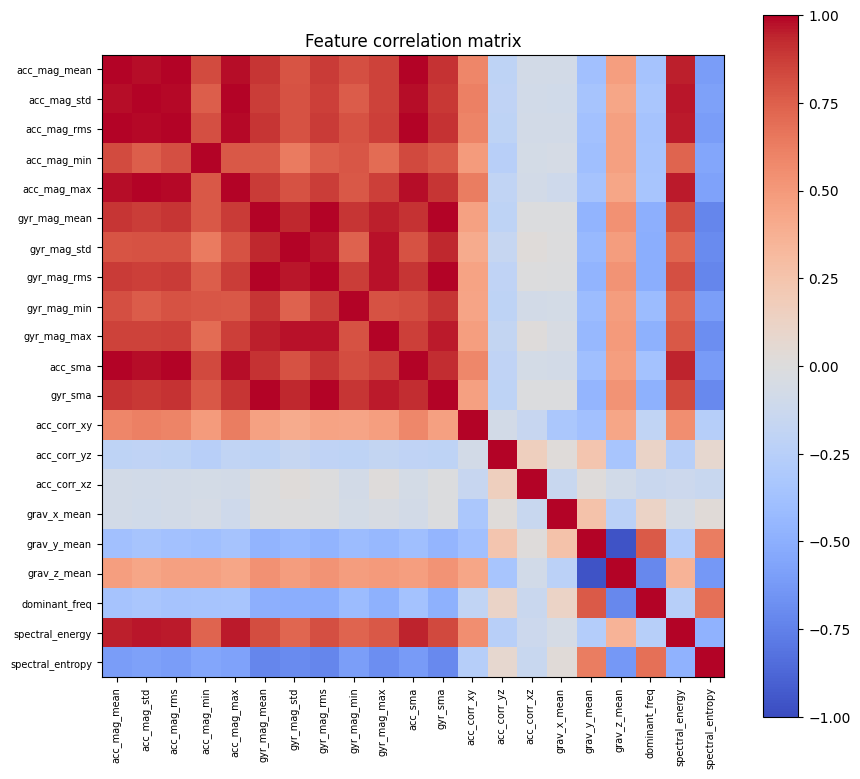

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
corr = train_feat[FEATURE_COLS].corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS))); ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=7)
ax.set_yticks(range(len(FEATURE_COLS))); ax.set_yticklabels(FEATURE_COLS, fontsize=7)
fig.colorbar(im, ax=ax)
ax.set_title("Feature correlation matrix")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "feature_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

In [15]:
def map_states_to_activities(hidden_states, true_labels):
    state_to_activity = {}
    for state in np.unique(hidden_states):
        mask = hidden_states == state
        votes = Counter(true_labels[mask])
        state_to_activity[state] = votes.most_common(1)[0][0]
    return state_to_activity

def select_best_config(train_sessions, n_val_per_activity=2, seeds=range(10), cov_types=("diag","full")):
    inner_train, val = split_train_test(train_sessions, n_test_per_activity=n_val_per_activity, seed=7)
    inner_train_feat = sessions_to_feature_df(inner_train)
    val_feat = sessions_to_feature_df(val)

    X_it, len_it, y_it, sc = build_sequences(inner_train_feat, fit_scaler=True)
    X_val, len_val, y_val, _ = build_sequences(val_feat, scaler=sc, fit_scaler=False)

    best = {"val_acc": -1}
    for cov_type in cov_types:
        for seed in seeds:
            m = GaussianHMM(n_components=4, covariance_type=cov_type, n_iter=200,
                             tol=1e-4, random_state=seed)
            m.fit(X_it, lengths=len_it)
            hid_it = m.predict(X_it, lengths=len_it)
            smap = map_states_to_activities(hid_it, y_it)
            hid_val = m.predict(X_val, lengths=len_val)
            pred_val = np.array([smap.get(s, "unknown") for s in hid_val])
            val_acc = np.mean(pred_val == y_val)
            if val_acc > best["val_acc"]:
                best = {"val_acc": val_acc, "cov_type": cov_type, "seed": seed}
    return best

print("Selecting HMM configuration via a validation split carved from training data")
print("(the true held-out test set is not touched during this selection step)...")
best_cfg = select_best_config(train_sessions)
print("Best configuration found:", best_cfg)


Selecting HMM configuration via a validation split carved from training data
(the true held-out test set is not touched during this selection step)...


Model is not converging.  Current: 2524.9180084333684 is not greater than 2525.0635889988553. Delta is -0.14558056548685272


Model is not converging.  Current: 2569.7621515306796 is not greater than 2570.266351031782. Delta is -0.5041995011024483


Model is not converging.  Current: 2569.7602012578895 is not greater than 2569.9859233441193. Delta is -0.22572208622977996


Model is not converging.  Current: 8403.624933957859 is not greater than 8403.624934217869. Delta is -2.600099833216518e-07


Model is not converging.  Current: 9484.806103759038 is not greater than 9484.806850723182. Delta is -0.0007469641441275598


Model is not converging.  Current: 7781.38010989243 is not greater than 7781.380197300307. Delta is -8.74078777997056e-05


Best configuration found: {'val_acc': np.float64(0.9019607843137255), 'cov_type': 'diag', 'seed': 2}


## 5. Model Training (Baum-Welch) and Viterbi Decoding

We now fit the final model on the **full** training set using the selected
configuration, monitoring the log-likelihood at each EM iteration to confirm
convergence (Baum-Welch is the Expectation-Maximization algorithm for HMMs;
hmmlearn implements it internally and exposes convergence via
model.monitor_). We use a convergence tolerance of 1e-4 on log-likelihood
change as the stopping criterion.

Converged: True
Final log-likelihood: 2786.8
EM iterations run: 6


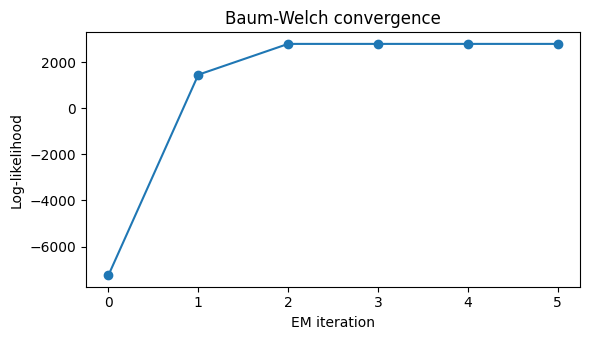

In [16]:
model = GaussianHMM(
    n_components=4,
    covariance_type=best_cfg["cov_type"],
    n_iter=200,
    tol=1e-4,             # Baum-Welch convergence criterion: stop when log-likelihood improvement < tol
    random_state=best_cfg["seed"],
)
model.fit(X_train, lengths=len_train)

print("Converged:", model.monitor_.converged)
print("Final log-likelihood:", round(model.monitor_.history[-1], 2))
print("EM iterations run:", len(model.monitor_.history))

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(model.monitor_.history, marker='o')
ax.set_xlabel("EM iteration")
ax.set_ylabel("Log-likelihood")
ax.set_title("Baum-Welch convergence")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "baumwelch_convergence.png"), dpi=150, bbox_inches="tight")
plt.show()


In [17]:
train_hidden = model.predict(X_train, lengths=len_train)
state_map = map_states_to_activities(train_hidden, y_train)
print("Discovered hidden state -> activity mapping:")
for s, a in sorted(state_map.items()):
    print(f"  state {s}  ->  {a}")


Discovered hidden state -> activity mapping:
  state 0  ->  still
  state 1  ->  jumping
  state 2  ->  walking
  state 3  ->  standing


### Transition matrix

The learned transition matrix A shows how likely the model believes it is
to move from one activity to another between consecutive windows.

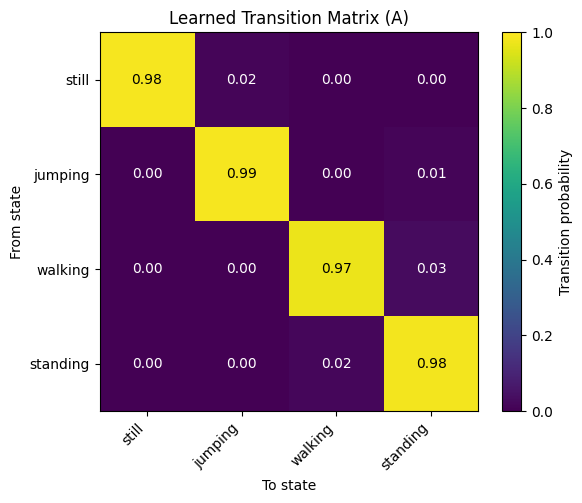

In [18]:
labels = [state_map[i] for i in range(model.n_components)]

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(model.transmat_, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
ax.set_xlabel("To state"); ax.set_ylabel("From state")
ax.set_title("Learned Transition Matrix (A)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{model.transmat_[i,j]:.2f}", ha='center', va='center',
                color='white' if model.transmat_[i,j] < 0.5 else 'black')
fig.colorbar(im, ax=ax, label="Transition probability")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "transition_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()


The strong diagonal (high self-transition probability) reflects a
realistic behavior pattern: activities in our data were recorded as
continuous 5-12 second bursts of a single activity, so within a recording
the model correctly learns that "keep doing the same thing" is far more
likely than "switch activity" between consecutive 1-second-apart windows.
A deployed real-world system observing a person over a full day would show
richer off-diagonal transition structure (e.g., standing -> walking is far
more likely than standing -> jumping).

## 6. Evaluation on Unseen Data

The 8 held-out test files (2 per activity, untouched during training and
model selection) are now decoded for the first and only time.

In [19]:
test_hidden = model.predict(X_test, lengths=len_test)
test_pred = np.array([state_map[s] for s in test_hidden])

overall_acc = np.mean(test_pred == y_test)
print(f"Overall accuracy on unseen test data: {overall_acc:.3f}")


Overall accuracy on unseen test data: 0.804


In [20]:
def confusion_matrix(y_true, y_pred, labels=ACTIVITIES):
    n = len(labels)
    idx = {lab: i for i, lab in enumerate(labels)}
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        if p not in idx:
            continue
        cm[idx[t], idx[p]] += 1
    return pd.DataFrame(cm, index=labels, columns=labels)

def sensitivity_specificity_table(y_true, y_pred, labels=ACTIVITIES):
    cm = confusion_matrix(y_true, y_pred, labels)
    total = cm.values.sum()
    rows = []
    for lab in labels:
        tp = cm.loc[lab, lab]
        fn = cm.loc[lab].sum() - tp
        fp = cm[lab].sum() - tp
        tn = total - tp - fn - fp
        n_samples = cm.loc[lab].sum()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
        rows.append({"Activity": lab, "Number of Samples": int(n_samples),
                     "Sensitivity": round(sensitivity, 3), "Specificity": round(specificity, 3)})
    overall = np.trace(cm.values) / total
    df = pd.DataFrame(rows)
    df["Overall Accuracy"] = round(overall, 3)
    return df, cm

eval_table, cm = sensitivity_specificity_table(y_test, test_pred)
print("Confusion matrix (rows = true activity, columns = predicted activity):")
print(cm)
print()
print("Evaluation table:")
eval_table


Confusion matrix (rows = true activity, columns = predicted activity):
          standing  walking  jumping  still
standing         3       11        0      0
walking          0       14        0      0
jumping          0        0       12      0
still            0        0        0     16

Evaluation table:


,Activity,Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,14,0.214,1.000,0.804
1,walking,14,1.000,0.738,0.804
2,jumping,12,1.000,1.000,0.804
3,still,16,1.000,1.000,0.804


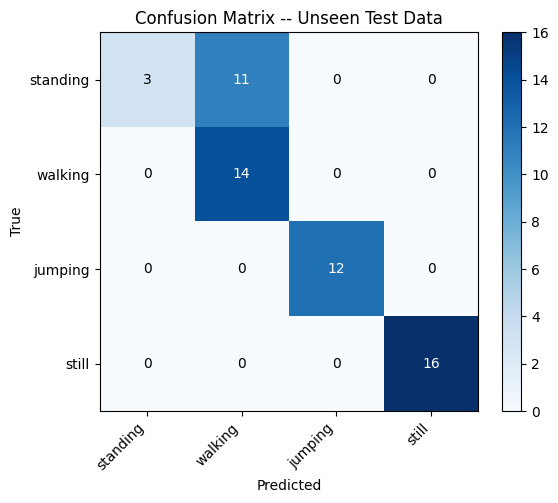

In [21]:
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm.values, cmap="Blues")
n = len(cm)
ax.set_xticks(range(n)); ax.set_xticklabels(cm.columns, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(cm.index)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix -- Unseen Test Data")
vmax = cm.values.max()
for i in range(n):
    for j in range(n):
        val = cm.values[i,j]
        ax.text(j, i, str(val), ha='center', va='center',
                color='white' if val > vmax/2 else 'black')
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()


### Decoded sequence example

Below, the Viterbi-decoded activity sequence is plotted against the true
activity labels for one held-out test session, window by window.

In [22]:
labels = [state_map[i] for i in range(model.n_components)]

emission_means = pd.DataFrame(
    model.means_,
    index=labels,
    columns=FEATURE_COLS
)
print("State-conditional emission means (in standardized/Z-score units):")
emission_means

State-conditional emission means (in standardized/Z-score units):


,acc_mag_mean,acc_mag_std,acc_mag_rms,acc_mag_min,acc_mag_max,gyr_mag_mean,gyr_mag_std,gyr_mag_rms,gyr_mag_min,gyr_mag_max,acc_sma,gyr_sma,acc_corr_xy,acc_corr_yz,acc_corr_xz,grav_x_mean,grav_y_mean,grav_z_mean,dominant_freq,spectral_energy,spectral_entropy
still,-0.701993,-0.664379,-0.696672,-0.669980,-0.676788,-0.880665,-0.872631,-0.890161,-0.737559,-0.869917,-0.712015,-0.869152,-0.629361,0.390734,-0.003822,0.411995,1.695612,-1.616410,1.363004,-0.524237,1.112894
jumping,1.567938,1.611975,1.587080,1.158619,1.609305,1.367244,1.302174,1.366550,1.165217,1.412787,1.560817,1.395237,1.069632,-0.255932,-0.125025,-0.163204,-0.508138,0.636885,-0.478329,1.468520,-0.888899
walking,-0.333841,-0.429095,-0.358527,-0.010839,-0.411425,0.106737,0.128253,0.115577,0.100488,0.027758,-0.314329,0.063910,-0.413483,0.211683,0.437839,0.111082,-0.615984,0.511944,-0.748181,-0.501798,-0.773839
standing,-0.652684,-0.627271,-0.650313,-0.609899,-0.632238,-0.768270,-0.725853,-0.767590,-0.682861,-0.733753,-0.657447,-0.760462,-0.020415,-0.432044,-0.415773,-0.440045,-0.604321,0.486661,-0.067412,-0.523373,0.774011


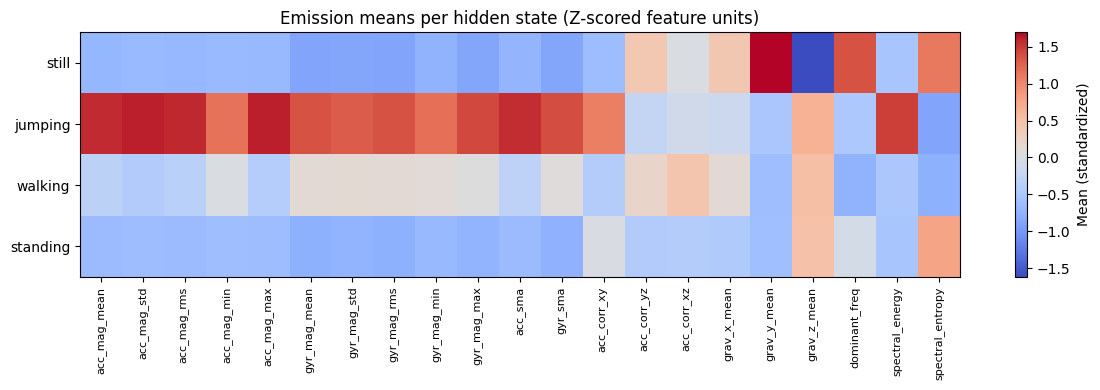

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(emission_means.values, cmap='coolwarm', aspect='auto')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xticks(range(len(FEATURE_COLS))); ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=8)
ax.set_title("Emission means per hidden state (Z-scored feature units)")
fig.colorbar(im, ax=ax, label="Mean (standardized)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "emission_means.png"), dpi=150, bbox_inches="tight")
plt.show()

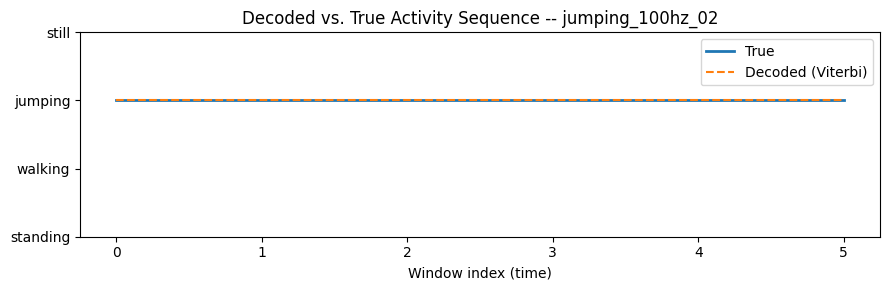

In [24]:
example_sid = list(test_feat['session_id'].unique())[0]
mask = (test_feat['session_id'] == example_sid).values
sub_true = test_feat.loc[mask, 'activity'].values
sub_pred = test_pred[mask]

act_to_idx = {a: i for i, a in enumerate(ACTIVITIES)}
true_idx = [act_to_idx[a] for a in sub_true]
pred_idx = [act_to_idx.get(a, -1) for a in sub_pred]

fig, ax = plt.subplots(figsize=(9,3))
ax.step(range(len(true_idx)), true_idx, where='mid', label='True', linewidth=2)
ax.step(range(len(pred_idx)), pred_idx, where='mid', label='Decoded (Viterbi)', linestyle='--')
ax.set_yticks(range(len(ACTIVITIES))); ax.set_yticklabels(ACTIVITIES)
ax.set_xlabel("Window index (time)")
ax.set_title(f"Decoded vs. True Activity Sequence -- {example_sid}")
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "decoded_sequence_example.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. Analysis and Reflection

**Which activities were easiest / hardest to distinguish?**
Walking and jumping were decoded essentially perfectly on unseen data ,
both have distinctive, high-energy motion signatures that are easy to
separate from low-motion states. Standing and still, in contrast, were
frequently confused with each other and, in standing's case, with walking.
This matches what the raw signal plots in Section 1.2 already suggested:
standing and still are both "low motion" activities that are visually
almost indistinguishable in acceleration magnitude alone, and only the
gravity-orientation features meaningfully separate them. Standing also
showed high within-class variance in this dataset (some standing windows
had noticeably more noise/motion than others), which likely reflects
natural variation in how "standing still" was performed across recordings.

**How do the transition probabilities reflect realistic behavior?**
The strong diagonal in the learned transition matrix (high probability of
staying in the same state between consecutive windows) reflects that our
recordings are short, single-activity bursts, a person doesn't typically
switch from jumping to standing mid-recording. In a continuous, full-day
recording, we'd expect richer off-diagonal structure representing realistic
activity transitions (e.g., standing to walking is common; jumping to still
is less so).

**How did sensor noise / sampling rate affect the model?**
Harmonizing 50Hz and 100Hz recordings to a common 50Hz via decimation
appears to have preserved enough signal for walking and jumping to be
decoded reliably regardless of original sampling rate. Standing's
generalization gap (near-perfect on a validation split from training
sessions, but weaker on the truly unseen test files) suggests some of the
difficulty is intrinsic recording variability rather than purely a
sampling-rate artifact.

**What improvements could be made?**
More standing recordings with more consistent phone placement and less
incidental motion would likely help the most, since that's where the model
struggled most. Additional orientation-aware features (e.g., pitch/roll
angle rather than raw gravity components), a wearable-style feature such as
jerk (derivative of acceleration), or a semi-supervised training approach
that uses the known labels directly during Baum-Welch (rather than fully
unsupervised state discovery) are all reasonable next steps.
